# Deep Fake Audio Detection using Machine Learning

This notebook presents an end-to-end pipeline for detecting deepfake audio using machine learning techniques. The model is trained on audio samples categorized as REAL and FAKE.

The workflow includes:
- Audio loading and preprocessing
- Feature extraction using MFCC
- Data balancing
- Model training using Artificial Neural Network (ANN)
- Evaluation using multiple metrics
- Final prediction on unseen audio samples

## Import Required Libraries

This section includes all the necessary libraries for audio processing, data handling, visualization, and model building.

In [1]:
import numpy as np
import pandas as pd
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

2026-04-05 07:50:57.621865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775375457.852914      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775375457.921393      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775375458.495788      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775375458.495839      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775375458.495842      17 computation_placer.cc:177] computation placer alr

## Load Dataset

The dataset contains audio files organized into two categories:
- REAL: Authentic audio samples
- FAKE: Deepfake generated audio samples

We load the dataset directory and verify the available folders.

In [2]:
audio_path = "/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO"

folders = os.listdir(audio_path)
print(folders)  # ['FAKE', 'REAL']

['FAKE', 'REAL']


## Audio Visualization

In this section, we visualize raw audio signals using waveform plots. This helps in understanding amplitude variations over time.

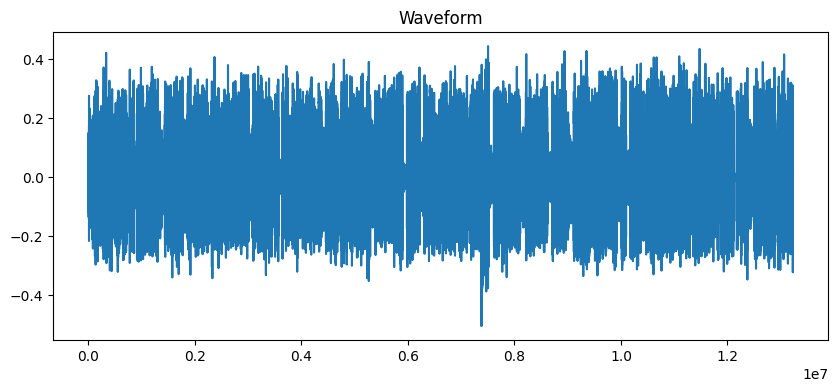

In [3]:
file_path = audio_path + "/REAL/biden-original.wav"
audio, sr = librosa.load(file_path)

plt.figure(figsize=(10,4))
plt.plot(audio)
plt.title("Waveform")
plt.show()

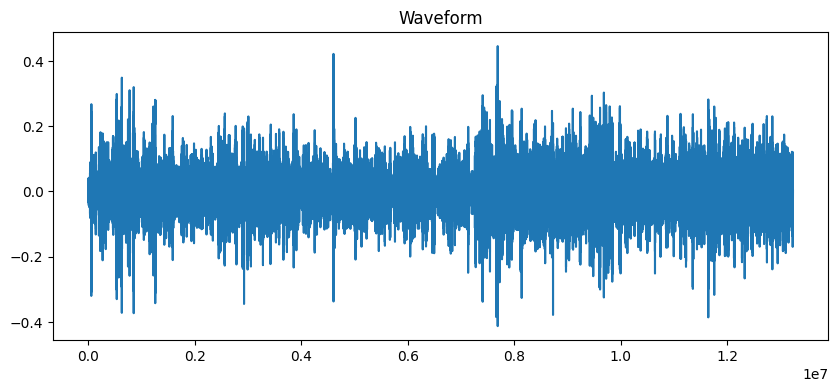

In [4]:
file_path = audio_path + "/REAL/taylor-original.wav"
audio, sr = librosa.load(file_path)

plt.figure(figsize=(10,4))
plt.plot(audio)
plt.title("Waveform")
plt.show()

## Spectrogram Analysis

Spectrograms provide a visual representation of frequency distribution over time. This helps in identifying patterns in real and fake audio.

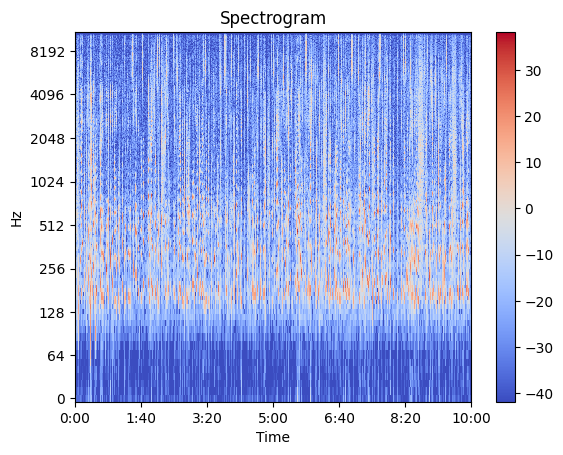

In [5]:
spec = librosa.stft(audio)
spec_db = librosa.amplitude_to_db(np.abs(spec))

librosa.display.specshow(spec_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()
plt.title("Spectrogram")
plt.show()

## Feature Extraction using MFCC

Mel-Frequency Cepstral Coefficients (MFCC) are extracted from audio signals. These features capture the timbral characteristics of audio and are widely used in speech and audio classification tasks.

In [6]:
import librosa
import numpy as np

def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None)
    except:
        import audioread
        with audioread.audio_open(file_path) as f:
            audio = np.concatenate([
                np.frombuffer(b, dtype=np.int16) for b in f
            ])
            sr = f.samplerate

    mfcc = librosa.feature.mfcc(y=audio.astype(float), sr=sr, n_mfcc=40)
    mfcc = mfcc.flatten()

    return mfcc

## Feature Padding

Since audio files vary in length, extracted features are padded or truncated to ensure a fixed input size for the model.

In [7]:
max_len = 4000

def pad_features(features):
    if len(features) < max_len:
        return np.pad(features, (0, max_len - len(features)))
    else:
        return features[:max_len]

## Data Preparation

We iterate through all audio files, extract features, and assign labels. Errors during processing are handled gracefully to ensure robustness.

In [8]:
data = []
labels = []

error_count = 0
success_count = 0

for folder in folders:
    path = os.path.join(audio_path, folder)

    for file in os.listdir(path):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(path, file)

        try:
            features = extract_features(file_path)
            features = pad_features(features)

            data.append(features)
            labels.append(folder)

            success_count += 1

        except Exception as e:
            print("Error:", file)
            error_count += 1

print("Success:", success_count)
print("Errors:", error_count)

Success: 64
Errors: 0


## Create Feature Dataset

The extracted features are stored in a DataFrame along with corresponding labels for further processing.

In [9]:
df = pd.DataFrame(data)
df['label'] = labels

df.head()

,0,1,2,3,4,5,6,7,8,9,...,3991,3992,3993,3994,3995,3996,3997,3998,3999,label
0,-384.821437,-358.656797,-357.000893,-362.361337,-369.748698,-371.906797,-377.691046,-377.115496,-377.710880,-377.720572,...,-328.662801,-321.477697,-318.537751,-303.532778,-283.141308,-283.257797,-298.046424,-291.077133,-283.027299,FAKE
1,-330.458544,-308.208294,-319.194032,-317.497847,-311.769803,-309.888452,-298.458638,-289.561971,-281.808482,-277.729195,...,-324.130475,-320.256051,-313.559362,-304.279703,-295.864120,-289.088973,-277.506923,-268.518872,-269.523979,FAKE
2,-527.928083,-528.360836,-528.808770,-528.401062,-526.779420,-523.248752,-512.735558,-493.722947,-443.391863,-330.269690,...,-396.984913,-402.702598,-415.723693,-429.550302,-458.123929,-479.601610,-457.949182,-403.790622,-402.522926,FAKE
3,-563.409512,-564.896324,-565.247857,-565.213357,-564.183959,-563.066199,-562.120637,-543.381851,-502.636356,-516.542109,...,-357.458456,-362.564291,-363.190870,-361.412457,-362.898365,-365.545211,-367.918691,-370.923556,-379.914911,FAKE
4,-530.425946,-531.133219,-531.271472,-531.277157,-531.304503,-531.306881,-531.318984,-519.926331,-500.454910,-499.766073,...,-379.925788,-379.688191,-379.800273,-383.215849,-385.504941,-389.542548,-390.757780,-397.284395,-397.503474,FAKE


## Label Encoding

Categorical labels (REAL and FAKE) are converted into numerical values using label encoding.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

df['label'].value_counts()

label
0    56
1     8
Name: count, dtype: int64

In [11]:
X = df.drop('label', axis=1)
y = df['label']

## Handle Class Imbalance

Random oversampling is applied to balance the dataset, ensuring equal representation of both classes.

In [12]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("After balancing:", pd.Series(y_res).value_counts())

After balancing: label
0    56
1    56
Name: count, dtype: int64


## Train-Test Split

The dataset is split into training and testing sets. Labels are converted into categorical format for model training.

In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Model Architecture

An Artificial Neural Network (ANN) is built using multiple dense layers, batch normalization, and dropout to improve generalization and reduce overfitting.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Dense(256, input_shape=(X_train.shape[1],), activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(2, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-05 07:55:32.757402: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,024,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,067,074 (4.07 MB)

 Trainable params: 1,066,306 (4.07 MB)

 Non-trainable params: 768 (3.00 KB)

## Model Training

The model is trained using early stopping to prevent overfitting. Validation loss is monitored to determine the optimal stopping point.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.4697 - loss: 1.0839 - val_accuracy: 0.3913 - val_loss: 12.6965
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6409 - loss: 0.7096 - val_accuracy: 0.3478 - val_loss: 16.3333
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5284 - loss: 0.8574 - val_accuracy: 0.3478 - val_loss: 9.6846
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6596 - loss: 0.7881 - val_accuracy: 0.3478 - val_loss: 8.3915
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6064 - loss: 0.6613 - val_accuracy: 0.3913 - val_loss: 5.0484
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6260 - loss: 0.8357 - val_accuracy: 0.3478 - val_loss: 3.2194
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6995 - loss: 0.5968 - val_accuracy: 0.3478 - val_loss: 3.0472
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6918 - loss: 0.6172 - val_accuracy: 0.3478 - val_lo

## Model Evaluation

The trained model is evaluated on the test dataset to measure its performance using accuracy.

In [16]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9130 - loss: 0.2211
Test Accuracy: 0.9130434989929199


## Confusion Matrix

A confusion matrix is plotted to visualize model performance across different classes.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


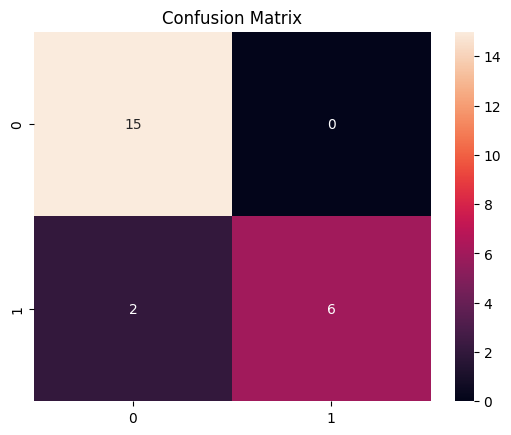

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Classification Report

Precision, recall, and F1-score are computed to provide a detailed evaluation of model performance.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.75      0.86         8

    accuracy                           0.91        23
   macro avg       0.94      0.88      0.90        23
weighted avg       0.92      0.91      0.91        23



## Accuracy Visualization

Training and validation accuracy are plotted to analyze the learning behavior of the model.

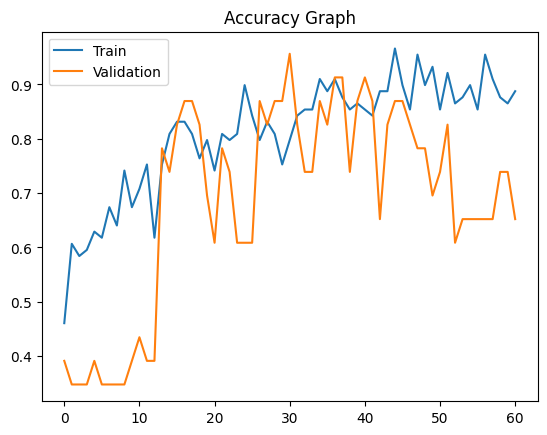

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy Graph")
plt.show()

## Audio Prediction Function

A function is defined to predict whether a given audio file is REAL or FAKE using the trained model.

In [20]:
def predict_audio(file_path):
    features = extract_features(file_path)
    features = pad_features(features)
    features = features.reshape(1, -1)

    result = model.predict(features)
    label = np.argmax(result)

    print("Prediction:", "REAL" if label == 1 else "FAKE")

## Testing on Sample Audio

The trained model is tested on multiple unseen audio samples to verify its prediction capability.

In [21]:
test_file = audio_path + "/REAL/biden-original.wav"
predict_audio(test_file)

test_file = audio_path + "/FAKE/linus-to-margot.wav"
predict_audio(test_file)

test_file = audio_path + "/FAKE/margot-to-obama.wav"
predict_audio(test_file)

test_file = audio_path + "/FAKE/musk-to-linus.wav"
predict_audio(test_file)

test_file = audio_path + "/FAKE/obama-to-ryan.wav"
predict_audio(test_file)

test_file = audio_path + "/FAKE/trump-to-Biden.wav"
predict_audio(test_file)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Prediction: REAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: FAKE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: FAKE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: FAKE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: FAKE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: FAKE


## Model Saving

The trained model is saved for future use and deployment.

In [22]:
model.save("deepfake_audio_model.keras")

## Conclusion

This notebook demonstrates a complete pipeline for detecting deepfake audio using MFCC features and an ANN model.

While the model performs well on the current dataset, performance may vary on larger and more diverse datasets. Future improvements include:
- Using CNNs on spectrogram images
- Training on larger datasets
- Hyperparameter tuning

This project serves as a strong foundation for real-world deepfake detection systems.